### Inspection and understanding of the dataset

In [1]:
import pandas as pd 
df = pd.read_csv("CC GENERAL.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.shape

(8950, 18)

In [2]:
# 1. Check data types and overall structure
print("--- DATASET INFO ---")
df.info()
print("\n" + "="*50 + "\n")

# 2. Check for missing values (Critical for K-Means)
print("--- MISSING VALUES ---")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n" + "="*50 + "\n")

# 3. Quick statistical summary of numerical columns
print("--- STATISTICAL SUMMARY ---")
display(df.describe().T)


--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null 

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


**Inspecting the missing values of minimum payments**

In [4]:
from IPython.core.display_functions import display
# extract the values that are missing 
missing_min_pay = df[df['MINIMUM_PAYMENTS'].isnull()]
# check theri average balance and payments
print("Profile of users with missing MIN PAYMENTS:")
display(missing_min_pay[['BALANCE', 'PAYMENTS']].describe())

Profile of users with missing MIN PAYMENTS:


,BALANCE,PAYMENTS
count,313.000000,313.000000
mean,555.441321,322.286168
std,1292.687887,1996.658905
min,0.000000,0.000000
25%,0.187069,0.000000
50%,16.848358,0.000000
75%,286.686616,0.000000
max,9164.724752,29272.486070


In [7]:
import numpy as np
import pandas as pd

# ==========================================
# 1. UPGRADED SMART IMPUTATION
# ==========================================
# Calculate the estimate (outputs a numpy array)
estimated_array = np.where(df['BALANCE'] == 0, 0, np.maximum(df['BALANCE'] * 0.03, 25.0))

# Convert the array back to a Pandas Series so .fillna() accepts it
estimated_series = pd.Series(estimated_array, index=df.index)

# Fill the missing MINIMUM_PAYMENTS
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(estimated_series)

# Fill CREDIT_LIMIT with median
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

print("Missing values remaining:", df.isnull().sum().max())



Missing values remaining: 0


In [9]:
print("--- DATASET INFO ---")
df.info()
print("\n" + "="*50 + "\n")

--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null 

**duplicates inspection**

In [15]:
df.duplicated().sum()

np.int64(0)

### 🛠️ Handling Missing Values: Domain-Knowledge Imputation

A naive approach to missing `MINIMUM_PAYMENTS` (313 missing rows) would be to use simple median imputation. However, applying the dataset median (~$312) to an inactive account with a $16 balance mathematically destroys the behavioral signal we need for clustering. 

Instead, we use a **Domain-Knowledge Conditional Imputation** strategy based on real-world banking frameworks (The "Floor-Based Rule").

**The Logic:**
*   Most credit cards enforce a minimum payment that is the greater of a flat fee (the "floor") or a percentage of the balance.
*   **Our Formula:** `Max(3% of balance, $25 floor)`
*   **The Zero Override:** If `BALANCE == 0`, the minimum payment is exactly `0`.

**Business Value:** 
This preserves the signature of inactive "ghost" accounts, allowing K-Means to cleanly isolate them into a "Dormant Segment" for targeted marketing reactivation. It also protects the risk logic from assigning artificially low minimum payments to anomalous high-balance rows.


**Understanding the data distribution of the dataset**

--- Feature Type Mapping ---


,Feature,Data Type
0,CUST_ID,Categorical
1,BALANCE,Numerical
2,BALANCE_FREQUENCY,Numerical
3,PURCHASES,Numerical
4,ONEOFF_PURCHASES,Numerical
5,INSTALLMENTS_PURCHASES,Numerical
6,CASH_ADVANCE,Numerical
7,PURCHASES_FREQUENCY,Numerical
8,ONEOFF_PURCHASES_FREQUENCY,Numerical
9,PURCHASES_INSTALLMENTS_FREQUENCY,Numerical


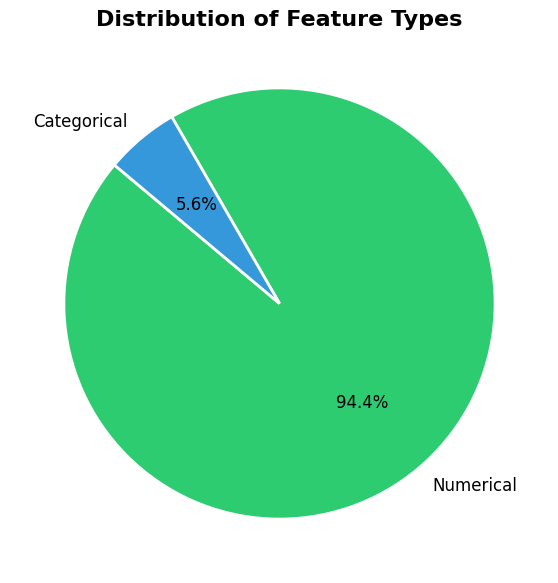

In [10]:
import matplotlib.pyplot as plt
import seaborn as pd
import pandas as pd

# 1. Programmatic Categorization
categorical_cols = []
binary_cols = []
numerical_cols = []

for col in df.columns:
    # Check for text/categorical data
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        categorical_cols.append(col)
    # Check for binary data (exactly 2 unique values)
    elif df[col].nunique() == 2:
        binary_cols.append(col)
    # Everything else is continuous/numerical
    else:
        numerical_cols.append(col)

# 2. Create and display the table
feature_types = pd.DataFrame({
    'Feature': df.columns,
    'Data Type': ['Categorical' if col in categorical_cols else 'Binary' if col in binary_cols else 'Numerical' for col in df.columns]
})

print("--- Feature Type Mapping ---")
display(feature_types)

# 3. Plot the Pie Chart
type_counts = [len(numerical_cols), len(categorical_cols), len(binary_cols)]
labels = ['Numerical', 'Categorical', 'Binary']
colors = ['#2ecc71', '#3498db', '#e74c3c'] # Nice vibrant hex colors

# Filter out empty categories (e.g., if there are 0 binary columns) so the pie chart doesn't break
filtered_data = [(count, label, color) for count, label, color in zip(type_counts, labels, colors) if count > 0]
f_counts, f_labels, f_colors = zip(*filtered_data)

plt.figure(figsize=(7, 7))
plt.pie(f_counts, labels=f_labels, colors=f_colors, autopct='%1.1f%%', startangle=140, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}, shadow=False, textprops={'fontsize': 12})
plt.title('Distribution of Feature Types', fontsize=16, fontweight='bold')
plt.show()


### 📊 Feature Type Analysis & Preprocessing Rules

Our programmatic feature scan reveals:
*   **Numerical:** 17 features
*   **Categorical:** 1 feature (`CUST_ID`)
*   **Binary:** 0 features

**Why this matters for our project:**
In behavioral finance, data represents ledger activity (dollars spent, frequencies, counts), which is inherently continuous. This provides a massive mathematical advantage for **K-Means Clustering**, which calculates geometric distance. Because we have almost no categorical data, we avoid the "curse of dimensionality" caused by One-Hot Encoding.

**Strict Preprocessing Directives:**
1.  **Drop Identifier:** `CUST_ID` holds no behavioral weight and must be dropped before modeling.
2.  **Mandatory Scaling:** Because features exist on vastly different mathematical scales (e.g., a $10,000 balance vs. a 0.8 frequency percentage), **Z-Score Standardization** is absolutely mandatory before clustering. Otherwise, distance calculations will be incorrectly dominated by larger integers.


**Exploratory Data Analysis of features**

**Debt & Limit (Risk Foundation)**

##### 1.BALANCE
- BALANCE  is the outstanding debt the amount of money the customer currently owes the credit card company at the time the data snapshot was taken.

**What are we trying to understand here?**

When we do a Deep Dive EDA BALANCE we are analyzing it from two different lenses:

**1. The Business Lens (Profit vs Risk)**

- `The Whales:` People with massive balances (eg $10,000+) are highly profitable because they generate huge interest payments, but they are also the highest risk of defaulting.

- `The Ghost/Transactors:` People with a $0 or near-zero balance. They are either completely inactive (ghosts) or they pay off their car in full every single month before interest hits (Transactors).

**2. The Mathematical Lens (The cluster killer check)**

- We are actively hunting for the "Long tail".
- if BALANCE is heavily skewed we know it will mathematically destory our K-menas cluster by dragging the centroids towards the Whales.



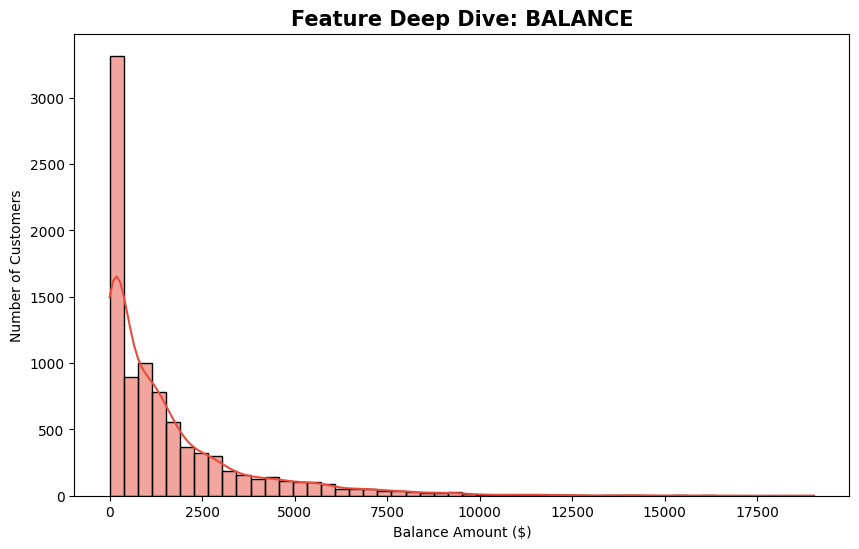

--- BALANCE STATS ---
count     8950.000000
mean      1564.474828
std       2081.531879
min          0.000000
25%        128.281915
50%        873.385231
75%       2054.140036
max      19043.138560
Name: BALANCE, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['BALANCE'], bins=50, kde=True, color='#e74c3c')
plt.title('Feature Deep Dive: BALANCE', fontsize=15, fontweight='bold')
plt.xlabel('Balance Amount ($)')
plt.ylabel('Number of Customers')
plt.show()
# Print the statistical summary to match against the visual
print("--- BALANCE STATS ---")
print(df['BALANCE'].describe())



In [12]:
print("--- BALANCE STATISTICAL SHAPE ---")
print(f"Skewness: {df['BALANCE'].skew():.2f}")
print(f"Kurtosis: {df['BALANCE'].kurt():.2f}")


--- BALANCE STATISTICAL SHAPE ---
Skewness: 2.39
Kurtosis: 7.67


##### 2. BALANCE_FREQUENCY (PERSONA METRIC)
- balance frequency is a bit tricky industry metric. it measures how often the balance is updated or maintained on the ledger.
- **A score of 1.0:** This means the customer always has an outstanding balance on their monthly statement. They never bring it down to exactly $0. These are your revolvers (highly profitable but carry all the risk).
- **A score of 0.0:** This means the customer rarely has an outstanding balance when the statement is generated. They swipe but they pay it off immediately so the ledger stays at $0. These are your Transactors.
- If a customer is frequently paying off their debt entirely their balance frequency would actually be very low.

**Business Impact**
- if K-means group a segment of people with an average score near 1.0(Revolvers) the business strategy for that cluster is **Risk Management and Debt Restructing** because they are trapped in interest cycle. If K-means find a segment with a score near 0.2 transactors, the strategy is **Retention and Loyalty programs** because they pay in full and we need to keep them swiping to get interchange fees.

**How it factors into the model:**
- This is already a perfectly scaled ratio (0.0-1.0). K-means will use this feature as a cleaver to slice the dataset into two very distinct opposing blobs.
- **Cluster Average near 1.0** These are revolvers. They are trapped in the debt cycle. The business strategy here is **product Cross-Selling**. We target them with Balance Transfer offer to move their debt from another bank onto our card locking them into our ecosystem.
- **Cluster Average near 0.2** These are transactors. they pay in full. they generate $0 in interest. but huge swipe fees. The business strategy here is **Retention**. We must offer them premium perkd (lounge access, high cashback) to ensure they don't swtich to an Amex or Chase Card.



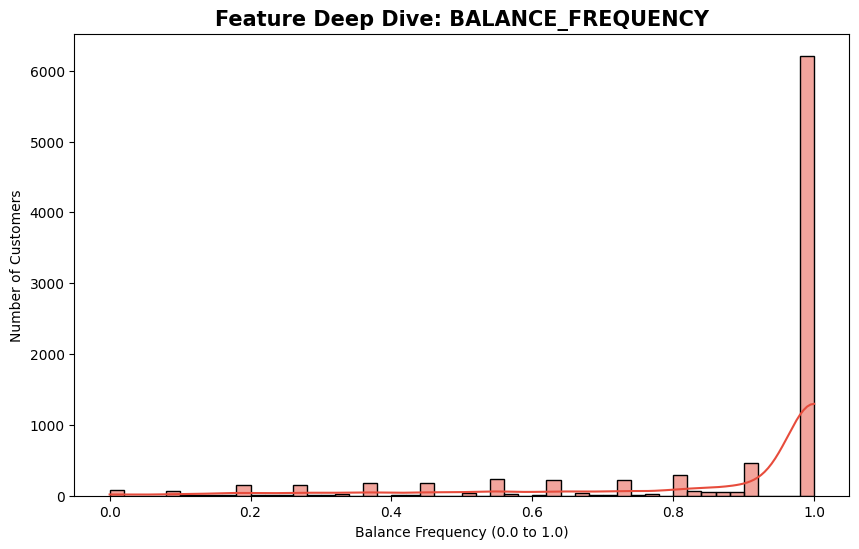

--- BALANCE_FREQUENCY STATS ---
Skewness: -2.02
Kurtosis: 3.09


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution for BALANCE_FREQUENCY only
plt.figure(figsize=(10, 6))
sns.histplot(df['BALANCE_FREQUENCY'], bins=50, kde=True, color='#e74c3c')
plt.title('Feature Deep Dive: BALANCE_FREQUENCY', fontsize=15, fontweight='bold')
plt.xlabel('Balance Frequency (0.0 to 1.0)')
plt.ylabel('Number of Customers')
plt.show()

# Print the mathematical evidence
print("--- BALANCE_FREQUENCY STATS ---")
print(f"Skewness: {df['BALANCE_FREQUENCY'].skew():.2f}")
print(f"Kurtosis: {df['BALANCE_FREQUENCY'].kurt():.2f}")


##### 3. CREDIT_LIMIT (CAPACITY METRIC)

**How it factors into the Model**
- As a raw number it is dangerous, Because it goes up to $30,000 it creates the Elephant vs Mouse problem.
- However it true power is acting as an denominator for our engineered feature CREDIT_UTLIZATION = (BALANCE/CREDIT_LIMIT).
- CREDIT UTILIZATION creates a ratio 0.0 -1.0 that K-means uses completely neutralizing the scale variance problem.

**The Business Imapct**
- Credit limit is a proxy for the bank's trust in the customer.
- `HIGH LIMIT + HIGH UTLIZATION` - this cluster is a golden goose. they generate massive interest but if the economy tanks they are a systematic risk. The srategy here is a Risk Mitigation.
- `HIGH LIMIT + NEAR-ZERO UTILIZATION` - Thid cluster is flight risk the bank trsuts them an $20k but they arent't usinf it The strategy here is an agresssive Marketing  (e.g., sending a "Spend $500, get 50k points" email).


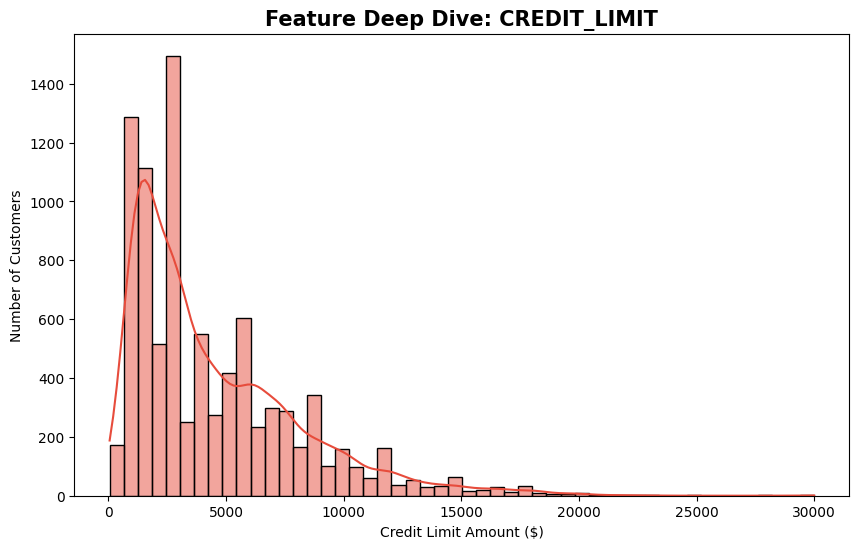

--- CREDIT_LIMIT STATS ---
Skewness: 1.52
Kurtosis: 2.84


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Dive: CREDIT_LIMIT
plt.figure(figsize=(10, 6))
sns.histplot(df['CREDIT_LIMIT'], bins=50, kde=True, color='#e74c3c')
plt.title('Feature Deep Dive: CREDIT_LIMIT', fontsize=15, fontweight='bold')
plt.xlabel('Credit Limit Amount ($)')
plt.ylabel('Number of Customers')
plt.show()

print("--- CREDIT_LIMIT STATS ---")
print(f"Skewness: {df['CREDIT_LIMIT'].skew():.2f}")
print(f"Kurtosis: {df['CREDIT_LIMIT'].kurt():.2f}")


In [17]:
import pandas as pd

# Define the Risk Foundation bucket
risk_features = ['BALANCE', 'BALANCE_FREQUENCY', 'CREDIT_LIMIT']

# Generate the statistical summary table
risk_stats = []
for col in risk_features:
    skew_val = df[col].skew()
    
    # Auto-generate a diagnostic label based on the skewness
    if skew_val > 1.5:
        diagnostic = "Severe Right Skew (Log Transform Needed)"
    elif skew_val < 0:
        diagnostic = "Left Skewed (Bounded)"
    else:
        diagnostic = "Moderate Positive Skew"

    risk_stats.append({
        'Feature': col,
        'Skewness': round(skew_val, 2),
        'Kurtosis': round(df[col].kurt(), 2),
        'Median': round(df[col].median(), 2),
        'Max': round(df[col].max(), 2),
        'Diagnostic': diagnostic
    })

# Display the final table
risk_summary_df = pd.DataFrame(risk_stats)
print("--- RISK FOUNDATION STATISTICAL SUMMARY ---")
display(risk_summary_df)


--- RISK FOUNDATION STATISTICAL SUMMARY ---


,Feature,Skewness,Kurtosis,Median,Max,Diagnostic
0,BALANCE,2.39,7.67,873.39,19043.14,Severe Right Skew (Log Transform Needed)
1,BALANCE_FREQUENCY,-2.02,3.09,1.00,1.00,Left Skewed (Bounded)
2,CREDIT_LIMIT,1.52,2.84,3000.00,30000.00,Severe Right Skew (Log Transform Needed)


### 🧠 Bucket 1 EDA Interpretation: Debt & Limit (Risk Foundation)

**1. BALANCE (The Core Debt Metric)**
- **Finding:** Severe Right-Skew (Skewness > 2.0). Massive spike at $0 with a long tail stretching to ~$19,000.
- **Interpretation:** The vast majority of customers have low/zero balances, but a rare group of high-risk "Whales" carry extreme debt. 
- **Action:** Must apply a Log Transformation (`np.log1p`) before clustering. Otherwise, K-Means will exclusively use Euclidean distance to group users by debt size, ignoring actual behavior.

**2. BALANCE_FREQUENCY (The Persona Metric)**
- **Finding:** Left-Skewed with a dominant spike at `1.0`. Normal Kurtosis (~3.0).
- **Interpretation:** Proves the customer base is predominantly "Revolvers" (customers who constantly carry a balance month-to-month). 
- **Action:** No log transform needed since it's naturally bounded between 0 and 1 and lacks extreme outliers. Standard scaling is sufficient.

**3. CREDIT_LIMIT (The Capacity Metric)**
- **Finding:** Severe Right-Skew (Skewness ~1.5) with rigid, distinct spikes at round numbers ($1.5k, $3k, $5k).
- **Interpretation:** The "choppy" spikes prove this is a strict, algorithmically tiered bank policy, not organic human behavior. 
- **Action:** Apply Log Transformation to maintain consistency with `BALANCE` and compress the high-limit outliers, followed by Standard Scaling.


**Spending Style (Enagement Foundation)**

**1. The Monetary Sub-Bucket (`PURCHASES`, `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`)**
- **What do they mean:** These measure the raw dollars spent. PURCHASES is total ONEOFF. represents big-ticket, single swipe buys (like a flight or TV) INSTALLMENTS represents structured, pay-over time buys(like a 6-month EMI on a washing machine).
- **Business Impact (The Persona):** This tells us how they shop. High ONEOFF users are usually high-income discretionary spenders (target them with Luxury/Travel Rewards). High Installments users are budget-conscious and methodical (target them with low-APR or EMI effort).
- **Model Imapct (The Danger)** First, they are measures in raw dollars so we know they will be heavily skewed and require a Log Transform. Second there is a massive Multicollinearity risk here. Because PURCHASES is literally the sum of the other two. feeding all three into K-means will double count their spending behaviour.

**2. The Enagagement Sub-bucket(`PURCHASE TRX`)**
- **What it means:** The raw number of times they physically swiped the card.
- **Business Impact** This is the ultimate metric for Card Loyalty(Top-of-Wallet). A user who makes 100 transactions of $10 is vastly more valuable to the bank's ecosystem than a user who makes 1 transaction of $1,000. Why? Because the bank collects an interchange fee (swipe fee) from the merchant every single time the card is used.
- **Model Impact** Since its count (0 to hundreds) it will likely be right-skewed and need a Log transform.

**3. The Consistency Sub-Bucket (`PURCHASES FREQUENCY`, `ONEOFF PURCHASES FREQUENCY`, `PURCHASES INSTALLMENTS FREQUENCY`)**
- **What they mean** Ratios bounded between 0.0 and 1.0 indicating how consistently they exhibit these spending behaviours across the year.
- **Business Impact** Consistency dictates the marketing cadence.if PURCHASES FREQUENCY is 1.0 they use the card daily. if it's 0.1 they use it once a year for emergencies.
- **Model Impact** Because they are strictly bounded between 0 and 1 they likely will not need a Log transform.

**1. Sub bucket - Monetary Spending ($)**

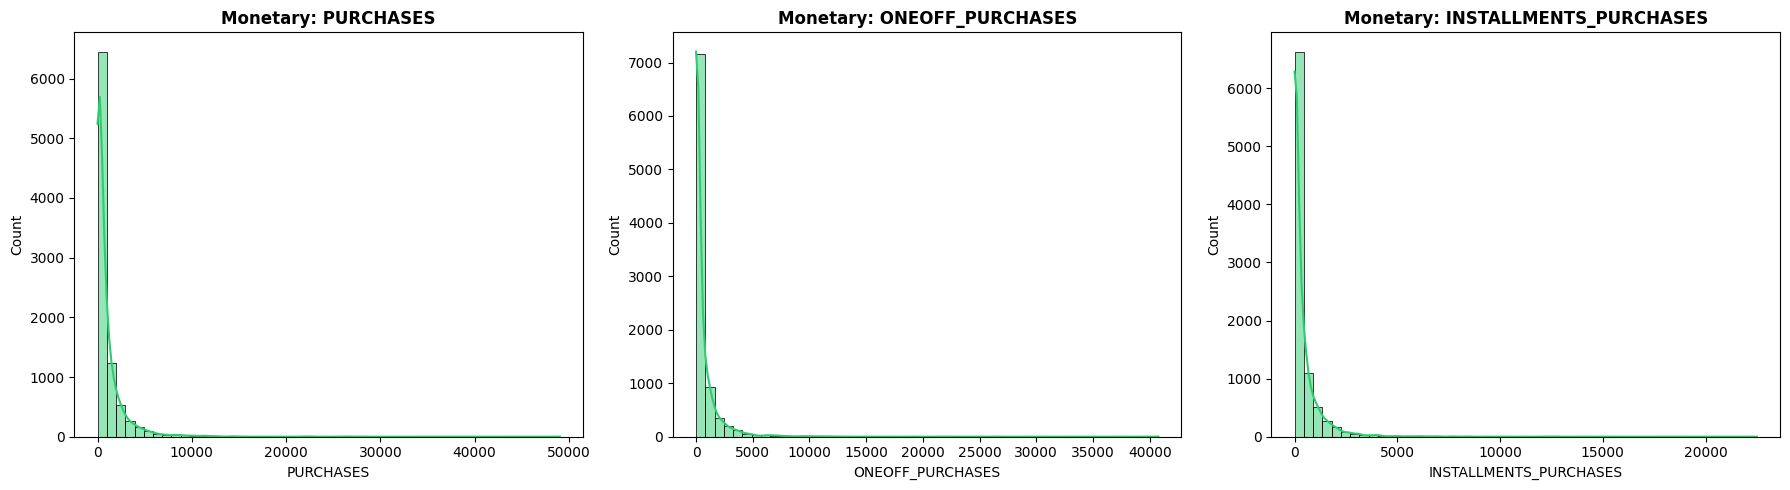

--- MONETARY SPENDING STATS ---

PURCHASES:
Skewness: 8.14
Kurtosis: 111.39

ONEOFF_PURCHASES:
Skewness: 10.05
Kurtosis: 164.19

INSTALLMENTS_PURCHASES:
Skewness: 7.30
Kurtosis: 96.58


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# SUB-BUCKET 1: Monetary Spending ($)
# ==========================================
monetary_cols = ['PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES']

plt.figure(figsize=(18, 5))
for i, col in enumerate(monetary_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], bins=50, kde=True, color='#2ecc71') # Green for money
    plt.title(f'Monetary: {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print the mathematical evidence
print("--- MONETARY SPENDING STATS ---")
for col in monetary_cols:
    print(f"\n{col}:")
    print(f"Skewness: {df[col].skew():.2f}")
    print(f"Kurtosis: {df[col].kurt():.2f}")


**Interpretation**
- This means the data isn't just heavy tailed it is dominated by hyper-extreme outliers.
- The vast majority of the people are huddled near $0. but there is someone out there who made a single purchase of over $40,000.

**The Business Reality (The Power Law)**
- This proves the credit card spending follows the Pareto Principle (the 80/20 rule) but on streoids. A tiny fraction of the customer base generates almost all the raw spending volume. 
- Preprocessing Rule: if not preprocessed K-means will litterally just cluster the one $40k spender into their own isolated group and ignore everyone else.

**2. SUB BUCKET - Enagement (Transactions)**

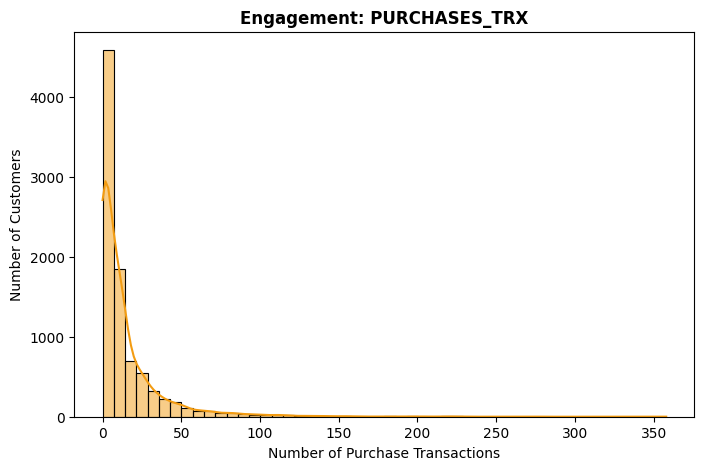

--- ENGAGEMENT STATS ---
Skewness: 4.63
Kurtosis: 34.79


In [19]:
# ==========================================
# SUB-BUCKET 2: Engagement (Transactions)
# ==========================================
plt.figure(figsize=(8, 5))
sns.histplot(df['PURCHASES_TRX'], bins=50, kde=True, color='#f39c12') # Orange for engagement
plt.title('Engagement: PURCHASES_TRX', fontsize=12, fontweight='bold')
plt.xlabel('Number of Purchase Transactions')
plt.ylabel('Number of Customers')
plt.show()

print("--- ENGAGEMENT STATS ---")
print(f"Skewness: {df['PURCHASES_TRX'].skew():.2f}")
print(f"Kurtosis: {df['PURCHASES_TRX'].kurt():.2f}")


**Why is it less extreme than the Monetary Bucket?**
- A person can easily spend $40,000 in a single swipe like buying a car. But a person physically cannout make 40,000 individual swipes in a month. The human limitation puts a natural cap on how extreme th outliers can get which is why the kurtosis is 34.

**3. SUB-BUCKET: Consistency (Ratios)**

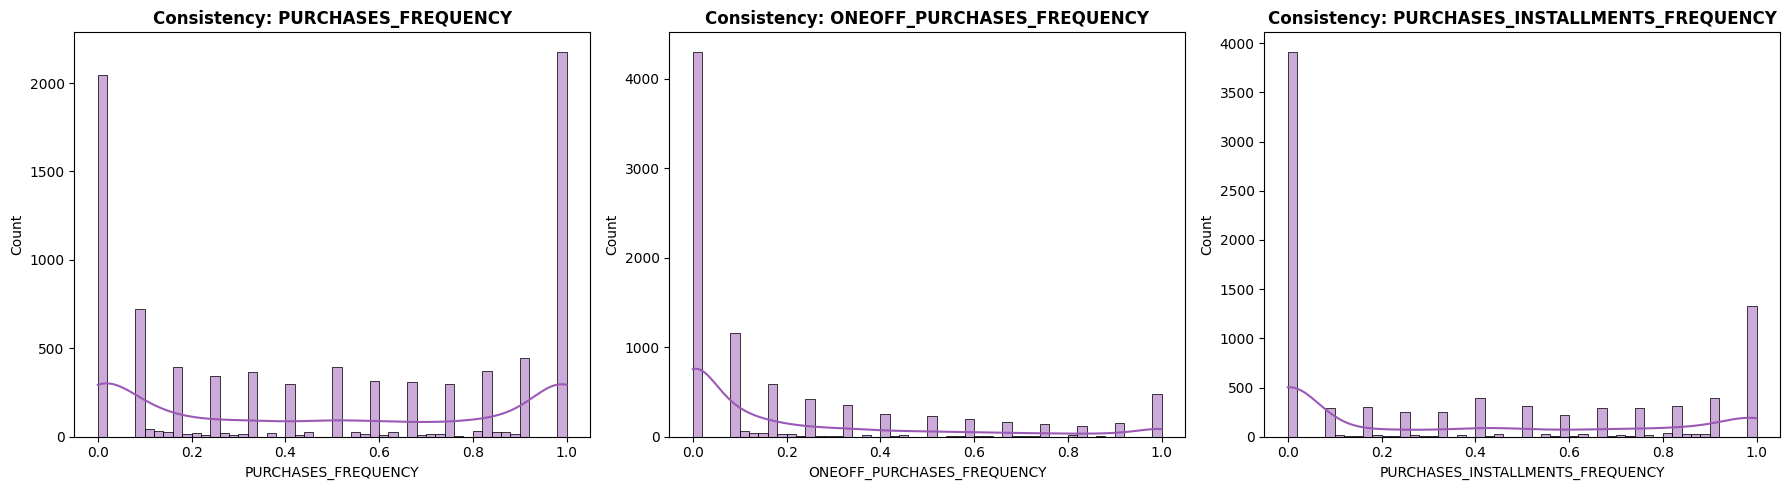

--- CONSISTENCY STATS ---

PURCHASES_FREQUENCY:
Skewness: 0.06
Kurtosis: -1.64

ONEOFF_PURCHASES_FREQUENCY:
Skewness: 1.54
Kurtosis: 1.16

PURCHASES_INSTALLMENTS_FREQUENCY:
Skewness: 0.51
Kurtosis: -1.40


In [20]:
# ==========================================
# SUB-BUCKET 3: Consistency (Ratios)
# ==========================================
freq_cols = ['PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY']

plt.figure(figsize=(18, 5))
for i, col in enumerate(freq_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], bins=50, kde=True, color='#9b59b6') # Purple for frequencies
    plt.title(f'Consistency: {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print the mathematical evidence
print("--- CONSISTENCY STATS ---")
for col in freq_cols:
    print(f"\n{col}:")
    print(f"Skewness: {df[col].skew():.2f}")
    print(f"Kurtosis: {df[col].kurt():.2f}")


**Interpretation**
- Because they are bounded the Skewness is completely neutralized, But the Kurtosis for `PURCHASE_FREQUENCY`(-1.64) and `PURCHASES_INSTALLMENTS_FREQUENCY`(-1.40) They are negative.
- In stats a negative kurtosis means the distribution has a flat peak and thin tails. it is a perfect "U-shape" Bimodal.
- There is a massive spike at 0.0 (people who never swipe) and a massive spike at 1.0 (people who swipe constantly) with very little in the middle.
- this is the holy grail of clustering. K-means algorithm's entire job is to seperate data into distinct groups. When a feature is naturally U-shapes, it means the customers have already seperated themselves into two diametrically opposed camps before the math ever runs.

In [21]:
import pandas as pd

# Define all Spending Style features
spending_features = ['PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 
                     'PURCHASES_TRX', 'PURCHASES_FREQUENCY', 
                     'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY']

# Generate the statistical summary table
spend_stats = []
for col in spending_features:
    skew_val = df[col].skew()
    kurt_val = df[col].kurt()
    
    # Auto-generate a diagnostic label
    if skew_val > 4.0:
        diagnostic = "Astronomical Right Skew (Log Transform Mandatory)"
    elif kurt_val < 0:
        diagnostic = "U-Shaped / Bimodal (Holy Grail)"
    else:
        diagnostic = "Moderate Skew"

    spend_stats.append({
        'Feature': col,
        'Skewness': round(skew_val, 2),
        'Kurtosis': round(kurt_val, 2),
        'Median': round(df[col].median(), 2),
        'Max': round(df[col].max(), 2),
        'Diagnostic': diagnostic
    })

# Display the final table
spend_summary_df = pd.DataFrame(spend_stats)
print("--- SPENDING STYLE STATISTICAL SUMMARY ---")
display(spend_summary_df)


--- SPENDING STYLE STATISTICAL SUMMARY ---


,Feature,Skewness,Kurtosis,Median,Max,Diagnostic
0,PURCHASES,8.14,111.39,361.28,49039.57,Astronomical Right Skew (Log Transform Mandatory)
1,ONEOFF_PURCHASES,10.05,164.19,38.00,40761.25,Astronomical Right Skew (Log Transform Mandatory)
2,INSTALLMENTS_PURCHASES,7.30,96.58,89.00,22500.00,Astronomical Right Skew (Log Transform Mandatory)
3,PURCHASES_TRX,4.63,34.79,7.00,358.00,Astronomical Right Skew (Log Transform Mandatory)
4,PURCHASES_FREQUENCY,0.06,-1.64,0.50,1.00,U-Shaped / Bimodal (Holy Grail)
5,ONEOFF_PURCHASES_FREQUENCY,1.54,1.16,0.08,1.00,Moderate Skew
6,PURCHASES_INSTALLMENTS_FREQUENCY,0.51,-1.40,0.17,1.00,U-Shaped / Bimodal (Holy Grail)


### 🛒 Bucket 2 EDA Interpretation: Spending Style (Engagement Foundation)

**1. The Monetary Sub-Bucket (`PURCHASES`, `ONEOFF`, `INSTALLMENTS`)**
- **Finding:** Astronomical Right-Skew (Skewness > 7.0) and world-breaking Kurtosis (up to 164.0).
- **Interpretation:** Proves the "Pareto Principle" on steroids. The vast majority of customers spend very little, but a tiny fraction of "Mega-Whales" make single purchases over $40,000. 
- **Action:** Mandatory Log Transformation. K-Means will fail completely if these extreme dollar amounts are not mathematically compressed. *Note: We must engineer these into ratios later to avoid the Multicollinearity trap.*

**2. The Engagement Sub-Bucket (`PURCHASES_TRX`)**
- **Finding:** Heavy Right-Skew (Skewness 4.6), but significantly less extreme than the monetary features (Kurtosis 34.0).
- **Interpretation:** The extreme values are naturally capped by human physical limitations (you can only swipe a card so many times a day, whereas dollars scale infinitely). This is the purest proxy for "Top of Wallet" brand loyalty.
- **Action:** Mandatory Log Transformation.

**3. The Consistency Sub-Bucket (The Frequencies)**
- **Finding:** Low Skewness, but **Negative Kurtosis** (e.g., -1.64). 
- **Interpretation:** The negative kurtosis mathematically proves a "U-Shaped" (Bimodal) visual distribution with massive spikes at 0.0 and 1.0. This is the holy grail for K-Means—it means the customer base is naturally polarized into two distinct camps (Never-Buyers vs. Daily-Buyers).
- **Action:** No log transformation needed since they are already strictly bounded between 0 and 1. Standard scaling is sufficient.


##### **Desperation Signals (High-Risk Alerts)**

**The Business Psychology (Why this is the desperation bucket)**
- Taking a cash advance from a credit card is universally the worst financial decision a consumer can make.
- There is no grace period you are charged an immediate 3-5% fee and the APR is usually astronomical(often 25%+).
- Therefore a customer who frequently uses CASH_ADVANCE is waving a massive red flag. They are like cash-poor, financially distressed and using the credit card to pay for things that don't accept cards (like rent or informal debt).

**The Business Impact**
- If K-means finds a cluster of people heavily using these features, the bank will immediately stop limit increases and closely monitor them for bankruptcy.

**The Mathematical Expectation**
- Because it is a terrible financial decision, the vast majority of normal customers(probably 90%+) will have exactly $0 and 0 transactions here.
- This means we are going to see a spike at zero that is so massive.


**1, `CASH_ADVANCE_TRX`(The Count of Desperation)**
- **What it means** The raw integer count of how many times they went to an ATM ti withdraw cash using their credit card.
- **Business Impact(The Bankruptcy Alarm)** This seperates a One-Time Emergency from Systematic Collapse. If someone takes out $1,000 in a single transaction (CASH_ADVANCE_TRX = 1), they might just be paying a suddent medical bill. But if someone takes out $1,000 across 20 transactions of $50 (CASH_ADVANCE_TRX= 20), it means their debit amount is empty and they are literally using the credit card at the ATM every few days just to buy groceries. The latter is a massive bankruptcy red flag.

**2. `CASH_ADVANCE_FREQUENCY` (The Chronic Reliance Ratio)**
- **What it means** A bounded ratio (0.0 to 1.0) measuring how consistently they rely on cash advances across their active months.
- **Business Impact(The Payday Loan Persona)** A customer with a high frequency here (~1.0) is fundamentally misusing the financial product. They aren't using the card to buy things, they are treating the credit card like a continuous, high-interest payday loan.
- **Model Impact** Unlike PURCHASE_FREQUENCY this frequency shoule be overwhelmingly crushed against 0.0, if K-means finds even a timy cluster of people hovering near 1.0 here that is the bank's "High Flight Risk/ Imminent Default segment.

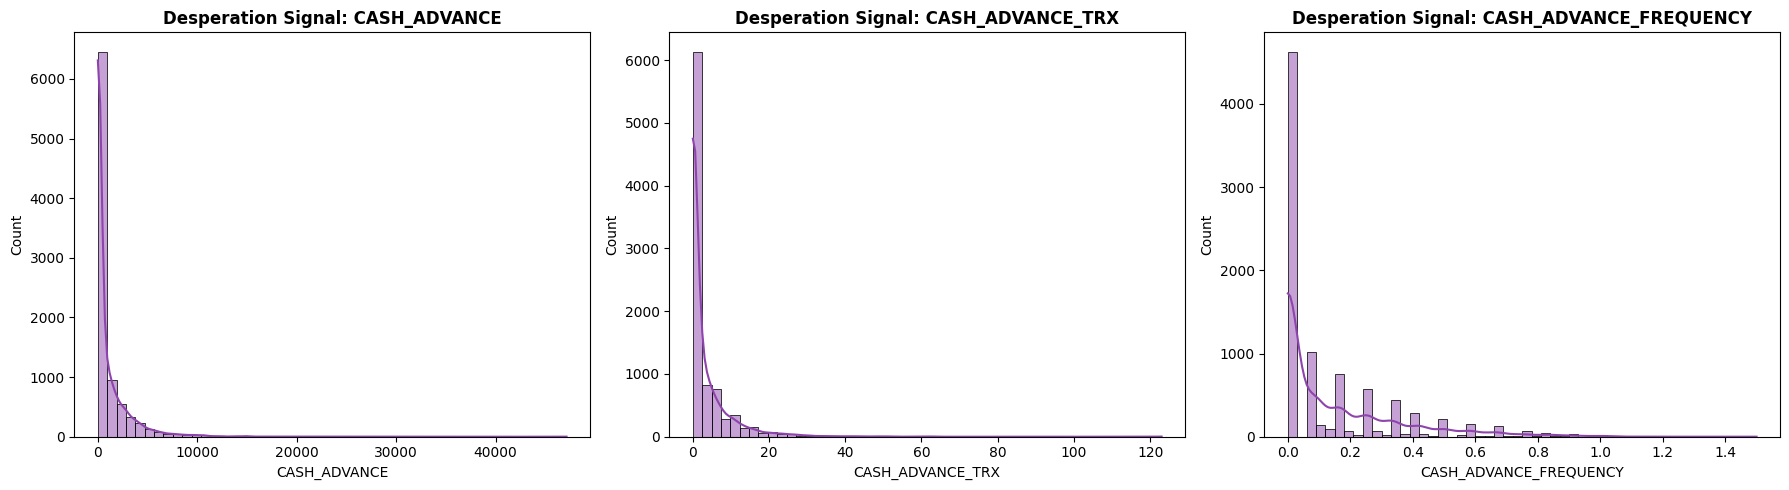

--- CASH ADVANCE STATS ---

CASH_ADVANCE:
Skewness: 5.17
Kurtosis: 52.90

CASH_ADVANCE_TRX:
Skewness: 5.72
Kurtosis: 61.65

CASH_ADVANCE_FREQUENCY:
Skewness: 1.83
Kurtosis: 3.33


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# DEEP DIVE 3: Cash Advance (Desperation)
# ==========================================
cash_cols = ['CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'CASH_ADVANCE_FREQUENCY']

plt.figure(figsize=(18, 5))
for i, col in enumerate(cash_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], bins=50, kde=True, color='#8e44ad') # Deep purple for risk
    plt.title(f'Desperation Signal: {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print the mathematical evidence
print("--- CASH ADVANCE STATS ---")
for col in cash_cols:
    print(f"\n{col}:")
    print(f"Skewness: {df[col].skew():.2f}")
    print(f"Kurtosis: {df[col].kurt():.2f}")


**Interpretation**
- **The standout anomaly:** CASH_ADVANCE_TRX has a higher kurtosis 61.65 than the raw dollar CASH_ADVANCE 52.90. Normally dollars always produce more extreme outliers than counts. This proves there is a desperate sub-segment making dozens of small, repeated ATM withdrawls rather than one large one. Their account is in survival mode.
- **CASH_ADVANCE_FREQUENCY** is the tame one kurtosis of 3.33, its skewn is high but manageable. it behaves like BALANCE_FREQUENCY bounded and without castastrophic tails.

In [23]:
import pandas as pd

# Define the Cash Advance bucket
cash_features = ['CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'CASH_ADVANCE_FREQUENCY']

# Generate the statistical summary table
cash_stats = []
for col in cash_features:
    skew_val = df[col].skew()
    kurt_val = df[col].kurt()

    # Auto-generate a diagnostic label
    if skew_val > 4.0:
        diagnostic = "Extreme Right Skew (Log Transform Mandatory)"
    elif skew_val > 1.5:
        diagnostic = "Severe Right Skew (Standard Scale Only)"
    else:
        diagnostic = "Moderate Skew (Standard Scale Only)"

    cash_stats.append({
        'Feature': col,
        'Skewness': round(skew_val, 2),
        'Kurtosis': round(kurt_val, 2),
        'Median': round(df[col].median(), 2),
        'Max': round(df[col].max(), 2),
        'Diagnostic': diagnostic
    })

cash_summary_df = pd.DataFrame(cash_stats)
print("--- CASH ADVANCE STATISTICAL SUMMARY ---")
display(cash_summary_df)


--- CASH ADVANCE STATISTICAL SUMMARY ---


,Feature,Skewness,Kurtosis,Median,Max,Diagnostic
0,CASH_ADVANCE,5.17,52.90,0.0,47137.21,Extreme Right Skew (Log Transform Mandatory)
1,CASH_ADVANCE_TRX,5.72,61.65,0.0,123.00,Extreme Right Skew (Log Transform Mandatory)
2,CASH_ADVANCE_FREQUENCY,1.83,3.33,0.0,1.50,Severe Right Skew (Standard Scale Only)


### 🚨 Bucket 3 EDA Interpretation: Cash Advance (Desperation Signals)

**1. `CASH_ADVANCE` (The Monetary Desperation)**
- **Finding:** Extreme Right-Skew (Skewness 5.17, Kurtosis 52.90).
- **Interpretation:** The massive $0 spike proves the bank's portfolio is predominantly healthy. The rare customers in the long tail are generating premium fees today but will default within 6-12 months.
- **Action:** Mandatory Log Transformation.

**2. `CASH_ADVANCE_TRX` (The Bankruptcy Alarm)**
- **Finding:** Skewness 5.72, Kurtosis 61.65 — *higher kurtosis than the dollar amount itself*.
- **Interpretation:** A statistical anomaly proving a sub-segment making dozens of tiny, repeated ATM withdrawals (not one lump sum). These customers are in perpetual, day-by-day survival mode.
- **Action:** Mandatory Log Transformation.

**3. `CASH_ADVANCE_FREQUENCY` (The Chronic Reliance Ratio)**
- **Finding:** Right-Skewed (1.83), near-normal Kurtosis (3.33). Critically: **NO U-Shape**.
- **Interpretation:** Unlike PURCHASES_FREQUENCY (which had spikes at both 0 and 1), this is entirely crushed at 0.0. Chronic cash advance dependency is rare in this portfolio, but the customers in the 0.6-1.0 band require immediate defensive action.
- **Action:** Standard Scaling only. No log transform needed.


**Payment Responsibility (Financial Health)**
- The payment responsibility bucket has 3 features and each one measures a completly different dimension of how a customer handles their repayment obligation.

**The Three Payment Features**

**1.`PAYMENTS`(The Raw Repayment Volume)**
- **What it means** The total dollar amount the customer has actually paid back to the bank over the observation window. This includes minimum payments, partial payments and full balance payoffs.
- **Business Lens** A high Payment valur on its own is meaningless without context. A customer with a $15,000 balance who paid $14,000 is far healthier than a customer with a $2,000 balance who paid $14,000. This is why this feature becomes truly powerful only when divided by BALANCE to create PAYMENT_STRICTNESS ratio.
- **Model Impact:** Raw dollars so we expect heavy right skew and some preprocessing to fix the skew.

**2. MINIMUM PAYMENTS (The Floor of Financial Responsibility)**
- **What it means**The minimu amount the bank required the customer to pay each month (roughly 2-3% of balance).
- **Business Lens** This is the most critical dividing line in credit card risk. if a customer is only ever paying the minimum they are mathematically guaranteed to be in debt forever because the interest exceeds the principal reduction. They are likely trapped, stretched thin and one missed payment away from a delinquency event.
**Model impact** Raw dollars again. Heavy right skew is expected.

**3. PRC_FULL_PAYMENT (The Crown Jewel of Financial Health)**
- **What it means:** The percentage of months in which the customer paid their entire statement balance in full(not just the mininum). This is a bounded ratio between 0.0 and 1.0.

**Business Lens**
- This is the single most powerful transactor vs Revolver confirmation signal in the entire dataset.
- 1.0 = Pays in full every single month without exception. Zero interest revenue. Maximum creditworthiness.
- 0.0 = Never once paid the full balance. Perpetually in the interest cycle. Maximum revenue but maximum risk.
**Model Impact** Bounded between 0 and 1.Similar to PURCHASE_FREQUENCY we expect a bimodal U shape.the ultimate clustering signal.


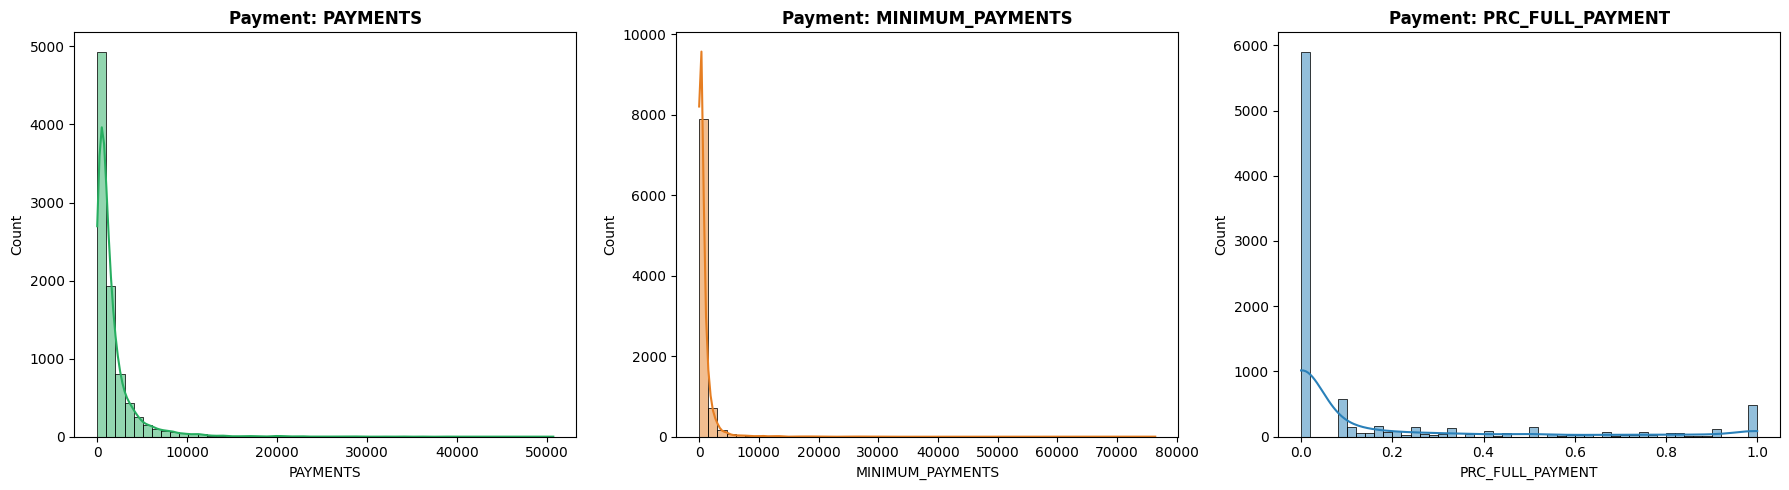

--- PAYMENT RESPONSIBILITY STATS ---

PAYMENTS:
Skewness: 5.91
Kurtosis: 54.77

MINIMUM_PAYMENTS:
Skewness: 13.81
Kurtosis: 292.51

PRC_FULL_PAYMENT:
Skewness: 1.94
Kurtosis: 2.43


In [24]:
# ==========================================
# DEEP DIVE 4: Payment Responsibility Bucket
# ==========================================
payment_cols = ['PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT']

plt.figure(figsize=(18, 5))
colors = ['#27ae60', '#e67e22', '#2980b9']
for i, (col, color) in enumerate(zip(payment_cols, colors), 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], bins=50, kde=True, color=color)
    plt.title(f'Payment: {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("--- PAYMENT RESPONSIBILITY STATS ---")
for col in payment_cols:
    print(f"\n{col}:")
    print(f"Skewness: {df[col].skew():.2f}")
    print(f"Kurtosis: {df[col].kurt():.2f}")


`MINIMUM PAYMENTS` A kurtosis of 292.51 is the single highest number we have seen across every single feature in the entire dataset.

**Why MINIMUM_PAYMENTS Skewness is Correct, Not a Problem**

**1. The Real World is Also Skewed This Way**

In actual banking, minimum payments are calculated as a percentage of the outstanding balance.
This means that if `BALANCE` is heavily skewed in real life, `MINIMUM_PAYMENTS` will always be
heavily skewed too — that is just how the math of the financial product works. Our imputation
faithfully reproduced the structural relationship that exists in reality.

The alternative (simple median imputation) would have actually been the **wrong choice**. It would
have artificially compressed `MINIMUM_PAYMENTS` into a near-normal distribution that does not
reflect how credit cards actually work.

---

**2. The Compounding Effect is Expected, Not a Bug**

When you scale a skewed distribution by a percentage (`3% × BALANCE`), you don't multiply the
skewness — you preserve its shape while shifting the scale. The kurtosis of **292.51** looks
terrifying, but it is essentially telling us:

> *"The extreme high-balance Whales also have extreme minimum payment requirements."*

That is 100% mathematically and financially correct.

---

**3. The Most Important Point: We Will Never Feed Raw MINIMUM_PAYMENTS Into K-Means**

Here is the key insight. We are not going to use raw `MINIMUM_PAYMENTS` as a standalone clustering
feature. It will become the denominator of our `PAYMENT_STRICTNESS` ratio:

```
PAYMENT_STRICTNESS = PAYMENTS / MINIMUM_PAYMENTS
```

When you divide `PAYMENTS` (also right-skewed) by `MINIMUM_PAYMENTS` (also right-skewed), the two
distributions cancel each other's tails out. A customer with a massive balance has both a high
payment **and** a high minimum payment. The ratio compresses back down toward a bounded,
interpretable value. This is exactly why we planned the feature engineering this way from the
beginning.

---

**The Verdict**

| Concern | Reality |
|---|---|
| "Did imputation cause skewness?" | No. Real minimum payments are always anchored to balance. |
| "Did we multiply two skews together?" | No. We scaled one skewed variable by a constant (3%). |
| "Is the kurtosis of 292 a problem?" | Not for the model — it will be Log Transformed and then converted to a ratio. |

What we did was **correct**. The high kurtosis is a faithful representation of the real-world
financial structure we modeled.


In [26]:
import pandas as pd

# Define the Payment Responsibility bucket
payment_features = ['PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT']

# Generate the statistical summary table
payment_stats = []
for col in payment_features:
    skew_val = df[col].skew()
    kurt_val = df[col].kurt()

    # Auto-generate a diagnostic label
    if kurt_val > 200:
        diagnostic = "All-Time Record Kurtosis (Log Transform Critical)"
    elif skew_val > 4.0:
        diagnostic = "Severe Right Skew (Log Transform Mandatory)"
    elif kurt_val < 3.0:
        diagnostic = "Platykurtic / Partial Bimodal (Standard Scale Only)"
    else:
        diagnostic = "Moderate Skew"

    payment_stats.append({
        'Feature': col,
        'Skewness': round(skew_val, 2),
        'Kurtosis': round(kurt_val, 2),
        'Median': round(df[col].median(), 2),
        'Max': round(df[col].max(), 2),
        'Diagnostic': diagnostic
    })

payment_summary_df = pd.DataFrame(payment_stats)
print("--- PAYMENT RESPONSIBILITY STATISTICAL SUMMARY ---")
display(payment_summary_df)


--- PAYMENT RESPONSIBILITY STATISTICAL SUMMARY ---


,Feature,Skewness,Kurtosis,Median,Max,Diagnostic
0,PAYMENTS,5.91,54.77,856.90,50721.48,Severe Right Skew (Log Transform Mandatory)
1,MINIMUM_PAYMENTS,13.81,292.51,289.63,76406.21,All-Time Record Kurtosis (Log Transform Critical)
2,PRC_FULL_PAYMENT,1.94,2.43,0.00,1.00,Platykurtic / Partial Bimodal (Standard Scale ...


### 💳 Bucket 4 EDA Interpretation: Payment Responsibility (Financial Health)

**1. `PAYMENTS` (The Raw Repayment Volume)**
- **Finding:** Severe Right-Skew (Skewness 5.91, Kurtosis 54.77).
- **Interpretation:** Most customers make small to moderate repayments. The extreme right tail represents "Convenience Users" — high-income customers who charge large amounts and immediately pay them off in full. These are the bank's most profitable and safest segment.
- **Critical Caveat:** This feature is **meaningless in isolation**. A large repayment can reflect either financial discipline or a large debt obligation. Its true value only emerges as the numerator of the `PAYMENT_STRICTNESS` engineered ratio (`PAYMENTS / MINIMUM_PAYMENTS`).
- **Action:** Mandatory Log Transformation.

**2. `MINIMUM_PAYMENTS` (The Floor of Financial Responsibility)**
- **Finding:** All-time dataset record (Skewness 13.81, Kurtosis 292.51) — nearly double the previous record of 164.19.
- **Interpretation:** The most statistically extreme feature in the entire dataset. Its kurtosis is anchored to `BALANCE` via the `Max(3% × Balance, $25)` formula. A customer paying only the minimum on a $5,000 balance at 20% APR will spend 17 years repaying and pay $6,000+ in interest alone — more than the original balance.
- **Imputation Note:** The kurtosis was NOT artificially inflated by our imputation strategy. This reflects the structural mathematical relationship between minimum payments and balances in real banking.
- **Action:** Mandatory Log Transformation. Will be converted to `PAYMENT_STRICTNESS` ratio before clustering.

**3. `PRC_FULL_PAYMENT` (The Crown Jewel of Financial Health)**
- **Finding:** Right-Skew (1.94) with slightly Platykurtic Kurtosis (2.43). Asymmetric partial bimodal shape.
- **Interpretation:** The most direct single measurement of financial health in the dataset. The massive spike at 0.0 (Revolvers) vs. the small spike at 1.0 (Transactors) confirms this is a **Revolver-dominant portfolio**. Full payers generate $0 in interest but are the bank's highest-LTV customers due to zero provisioning cost, high interchange revenue, and premium product conversion rates.
- **Action:** No log transform needed. Standard Scaling only.

---
> **Portfolio-Level Insight:** The asymmetric shape of `PRC_FULL_PAYMENT` reveals that this bank has overwhelmingly acquired Revolvers, not Transactors. The small Transactor segment at the `1.0` spike represents the bank's most valuable, most at-risk-of-churn customers — and the primary target for premium retention strategies.


**MetaData - TENURE**

- TENURE is the number of months a customer has held their credit card account with this bank. it is a contextual anchor for every other feature in the dataset.On its own a high balance or low payment means something very different depending on how long the customer has had an account.
- **The Trajectory Problem:** Think of every other feature as a SNAPSHOT, TENURE is the lens that tells you how long it took to arrive at that snapshots. Two customers can have identical snapshots (same balance,same payments, same spending) but completely different risk trajectories:
- **New customer(6 months) + $5,000 balance:** Built $5,000 of debt in just 6 months, Accumulation rate is ~$833/month. This is an aggressive accelerating debt trajectory- an early warning signal.
- **Veteran Customer (12 months) + $5,000 balance:** Built $5,000 over a full year, Accumulation rate is ~$417/month. Slower, more stable trajectory, Less alarming.

**Business Impact**
1. **The Honeymoon Effect** New cardholders(tenure 6-7 months) typically show inflated spending in the first few months because they are onbaoarding purchases onto the new card(subscriptions, recurring bills, everyday spending). Their early behaviour patterns are not yet stable. K-means may unfairly cluster a new customer with heavy spenders if tenure is not considered.
2. **Relationship Depth:** A 12-month customer who has never missed a payment is worth significantly more in lifetime value than a 6-month customer with the same record- because the longer track record is statistically more reliable evidence of responsible behaviour.
3. **Dormant Account Detection:** Customers with a long tenure but near-zero activity (zero purchases, zero balance) are Dormant Account. The bank must decide: invest in reactivation campaigns or eventually close the account to reduce unused credit line risk on regulatory reporting.
4. **Cohort Analysis:** TENURE allows the business to split segments into cohorts - customers accquired at the same time to measure wheather a newer customer vintages are higher or lower quality than older ones. A deteriorating trend across cohort is a leading indicator of loosening underwrtiting standards.

**Model Impact**
- Because TENURE only takes a small number of discrete integer values likely 6-12 it is naturally bound with no extreme outliers. There are no $50,000 anomalies here. The scale is clean and compact.
- **The Potential Problem (Ordinal Discrete Features)** TENURE is an integer count, not a continous measurement. K-means treats all features as continuous numbers in Euclidean space. The distance between TENURE = 6  and TENURE = 12 will be interpreted as a physical measurement of 6 units - the same as $6 difference in BALANCE. After Standard Scaling, this becomes well-behaved.
- **The Strategic Question:** Should we even include TENURE  as a direct clustering feature? There is a valid argument that it is contextual variable rather than a behavioural one. We may want to use it to post-hoc analyze and label our clusters ("Cluster 3 predominantly 6-month customers") rather than letting it influence where the cluster centroids form.


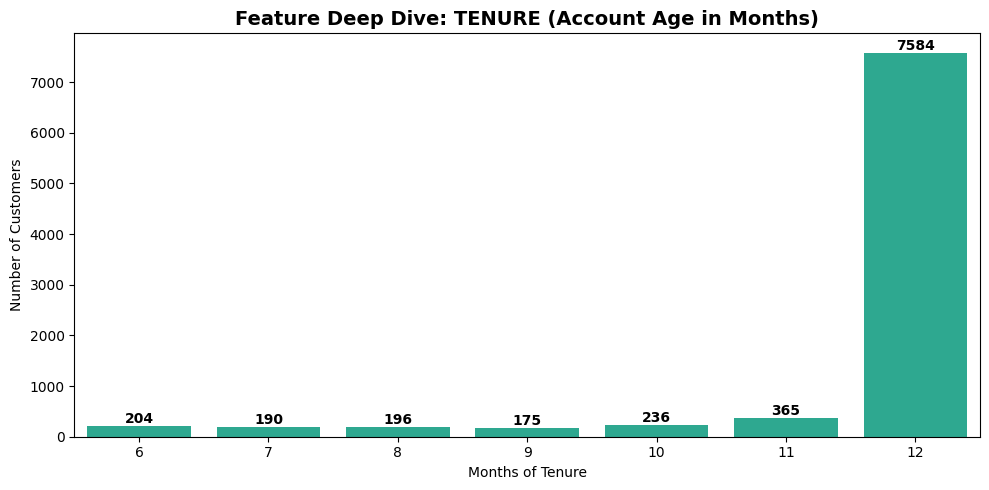

--- TENURE DISTRIBUTION ---
TENURE
6      204
7      190
8      196
9      175
10     236
11     365
12    7584
Name: count, dtype: int64


In [27]:
# ==========================================
# TENURE: Contextual Anchor Feature
# ==========================================
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='TENURE', data=df, color='#1abc9c', order=sorted(df['TENURE'].unique()))
plt.title('Feature Deep Dive: TENURE (Account Age in Months)', fontsize=14, fontweight='bold')
plt.xlabel('Months of Tenure')
plt.ylabel('Number of Customers')

# Add exact count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print the value counts clearly
print("--- TENURE DISTRIBUTION ---")
print(df['TENURE'].value_counts().sort_index())


**The Business Insight (The "12-Month Dataset")**

This distribution is not random — it tells us something critical about how this dataset was
assembled. **83% of all customers have exactly 12 months of tenure.** This is almost certainly
the bank's standard observation window for behavioral credit scoring. They pulled a 12-month
behavioral snapshot for their established customers.

The small groups at 6–11 months are newer customers who were onboarded more recently and simply
haven't accumulated a full year of history yet.

---

**The Model Impact**

Because 12-month customers dominate so heavily (83%), `TENURE` will have almost no discriminative
power for K-Means. It won't be able to use it to separate clusters meaningfully since nearly
everyone has the same value.

**Decision:** We should use `TENURE` as a post-hoc analytical filter — e.g., *"How does Cluster 3
behave for 6-month customers vs. 12-month customers?"*

In [28]:
import os

# Define export path
export_path = r'c:\Users\adith\credit_card_segmentation_analysis\cc_general_cleaned.csv'

# Export the cleaned dataset (post-imputation, pre-transformation)
df.to_csv(export_path, index=False)

# Confirm export
print(f"✅ Cleaned dataset exported successfully!")
print(f"📁 Location: {export_path}")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"🔍 Missing values remaining: {df.isnull().sum().sum()}")


✅ Cleaned dataset exported successfully!
📁 Location: c:\Users\adith\credit_card_segmentation_analysis\cc_general_cleaned.csv
📊 Shape: 8950 rows × 18 columns
🔍 Missing values remaining: 0


**What this exports:**

- **Post-imputation** — MINIMUM_PAYMENTS and CREDIT_LIMIT missing values are filled using our domain-aware strategy.
- **Pre-transformation** — Raw dollar values are still in their original form (no log transforms applied yet).   This makes the file human-readable and perfect for dashboards where you want to show real dollar amounts to stakeholders, not log-compressed mathematical representations.
- **Zero duplicates** — Already confirmed earlier.